# Streif Jump Simulation

This jupyter notebook should show how the Streif jump was made less dangerous over the last decades. The initial simulation uses the approximate shape of the jump in the your 2009 when Daniel Albrecht had his major accident.

## 1 Modelling the jump

There are no 3D scanned models available to us, therefore we give our best try to model the shape in a 2D way, so the jump can be simulated. To better understand what is happening, an illustration should help. 

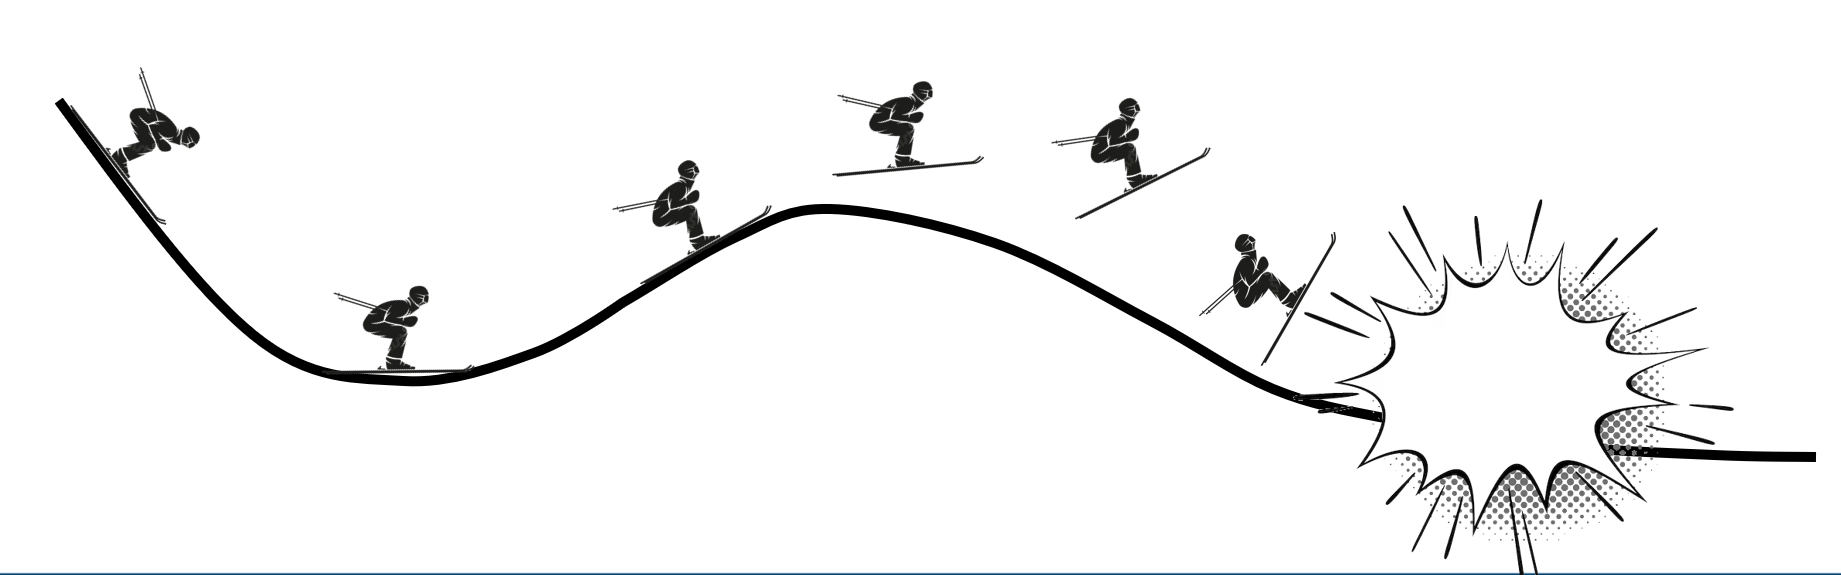

For a proper simulation we need the shape not in a drawing but as a function or discretised datapoints. Therefore, we need to create such data. 

### 1.1 Shape Creation

In a first step we try to get the discretised shape of the jump. We did this approximatey by using AI with this given shape. 
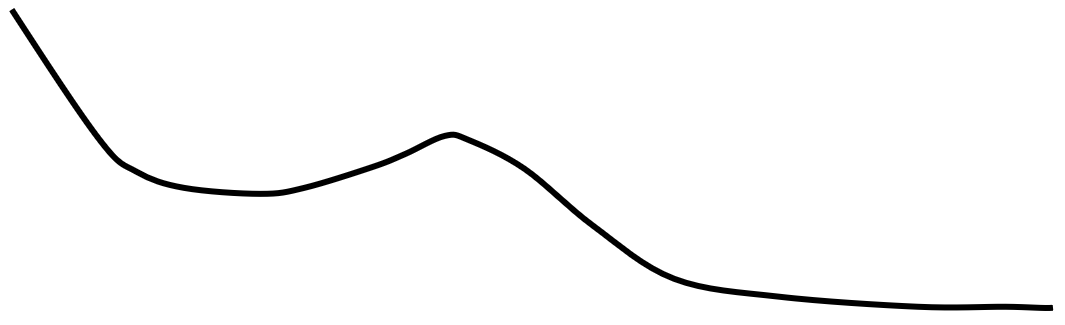
We got back the following arrays:

In [ ]:
import numpy as np  

# This is the new shape, which is less agressive and is the one that is used today
x =np.array([0, 3.3, 6.7, 10, 13.3, 16.7, 20, 23.3, 26.7, 30,
     33.3, 36.7, 40, 43.3, 46.7, 50, 53.3, 56.7, 60, 63.3,
     66.7, 70, 73.3, 76.7, 80, 83.3, 86.7, 90, 93.3, 96.7, 100])

y = np.array([98.8, 78.8, 58.0, 40.2, 28.1, 23.3, 22.1, 24.1, 29.1, 37.0,
     47.4, 57.0, 65.2, 69.7, 68.5, 65.1, 60.4, 53.5, 44.8, 36.0,
     26.2, 18.5, 14.1, 10.9, 7.9, 5.5, 3.8, 2.6, 1.9, 1.4, 1.2])

x=x*4
y=y*0.3

'x = np.array([\n     0.0,  30.4,  60.8,  91.2, 121.5, 151.9, 182.3, 212.7,\n   243.1, 273.5, 303.8, 334.2, 364.6, 395.0, 425.4, 455.8,\n   486.2, 516.5, 546.9, 577.3, 607.7, 638.1, 668.5, 698.8,\n   729.2, 759.6, 790.0, 820.4, 850.8, 881.2, 911.5, 941.9,\n   972.3, 1002.7, 1033.1, 1063.5, 1093.8, 1124.2, 1154.6,\n   1185.0\n])\n\ny = np.array([\n     3.4,  44.4,  90.5, 134.6, 171.8, 189.8, 200.8, 206.2,\n   209.0, 210.6, 210.1, 204.1, 195.6, 186.0, 175.6, 162.4,\n   147.6, 147.7, 160.9, 177.6, 200.7, 227.3, 251.7, 274.8,\n   295.3, 309.2, 317.3, 322.0, 325.3, 328.7, 331.6, 334.0,\n   336.1, 337.8, 339.2, 340.0, 339.8, 339.2, 339.9, 342.2\n])\n\nx=x*0.4\ny=(-y+np.max(y))*0.1'

We scaled the array a bit so it fits the approximate scales in the real world

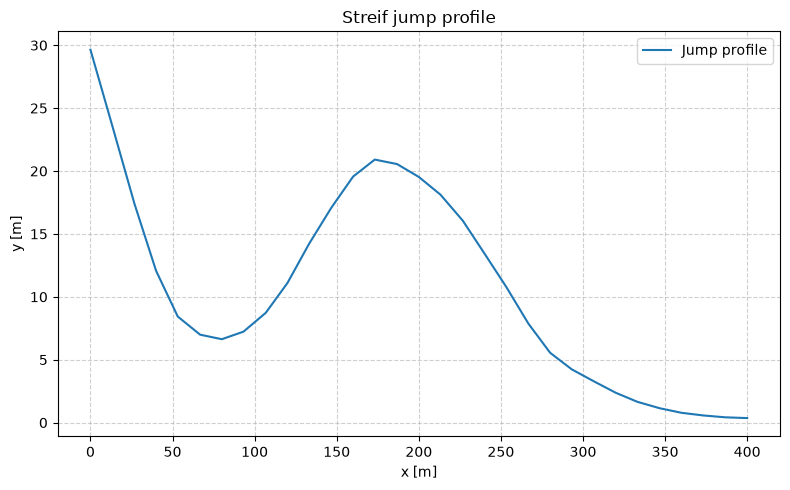

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Jump profile')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Streif jump profile')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Then we use a Cubic spline fit to get a better and smooth function for the shape.

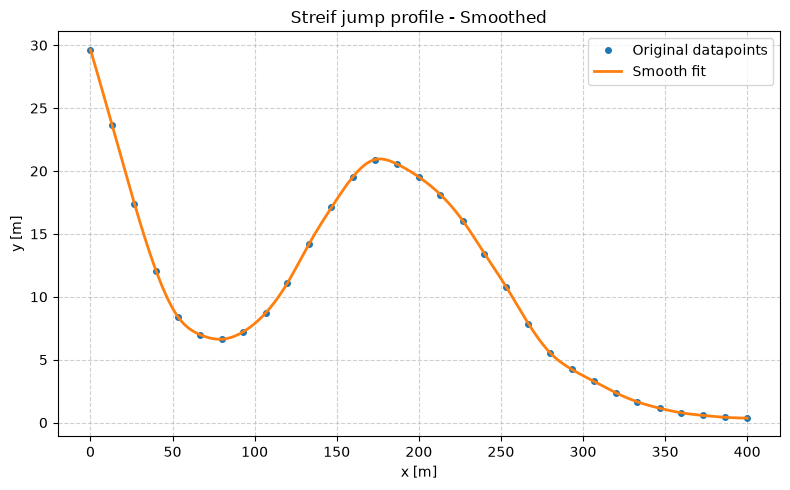

In [3]:
from scipy.interpolate import CubicSpline

# Create a cubic spline interpolation
cs = CubicSpline(x, y)

# Generate smooth points with higher resolution
x_smooth = np.linspace(x.min(), x.max(), 500)
y_smooth = cs(x_smooth)

# Calculate the derivative of the cubic spline
cs_derivative = cs.derivative()

# Plot both the original and smooth curve
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Original datapoints', markersize=4)
plt.plot(x_smooth, y_smooth, label='Smooth fit', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Streif jump profile - Smoothed')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 1.2 The Modelling of the jump

As the shape seems to be clear, we have to model the jump next. As this is our first approach we will try to model it as simple as possible. This means there are some major simplifications that we should at least mention:
* We model the skiier as one point of mass 
* We have no air drag
* We have no friction between the slope and the skis

Additionally we have some starting and boundary conditions for the simulation:
* The skier has a total mass of 100 kg
* The initial speed of the skier is 30 m/s

You can get the slope of the ski slope

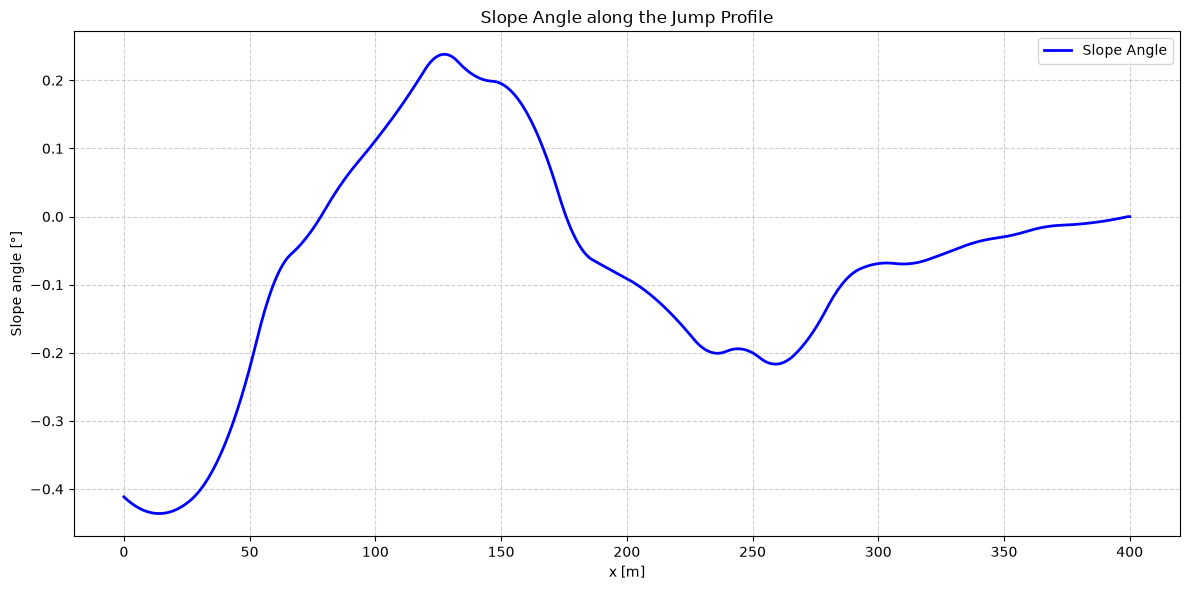

In [4]:
# slope angle calculation based on x_smooth and y_smooth
slope_angle = np.arctan2(np.diff(y_smooth), np.diff(x_smooth))
# append the last value at the end to match the length of x_smooth
slope_angle = np.append(slope_angle, slope_angle[-1])

# Plot trajectory
plt.figure(figsize=(12, 6))
plt.plot(x_smooth, slope_angle, 'b-', linewidth=2, label='Slope Angle')
plt.xlabel('x [m]')
plt.ylabel('Slope angle [°]')
plt.title('Slope Angle along the Jump Profile')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

First we set the boundary and initial conditions. Simulation configuration is included as well.

In [5]:
# Physical simulation of a skier on the Streif jump
# Initial conditions
mass = 100  # kg
g = 9.81  # m/s^2
v0 = 40  # m/s initial speed
compression = 1.2 # m stated state distance for the spring mass damper system
max_hight_free_fall_condition = 1.6 # m if the skier is more than this distance above the slope, they are in free fall

# Calculate initial velocity components
# Initial direction is tangent to the slope at the start
dx = x_smooth[1] - x_smooth[0]
dy = y_smooth[1] - y_smooth[0]
slope_length = np.sqrt(dx**2 + dy**2)
v0x = v0 * dx / slope_length
v0y = v0 * dy / slope_length


# Simulation parameters
dt = 0.0001  # time step in seconds
time_steps = 500000
t = np.zeros(time_steps)
pos_x = np.zeros(time_steps)
pos_y = np.zeros(time_steps)
vel_x = np.zeros(time_steps)
vel_y = np.zeros(time_steps)
slope_angle_sim = np.zeros(time_steps)

# Initial conditions
pos_x[0] = x_smooth[0]
pos_y[0] = y_smooth[0]+compression
vel_x[0] = v0x
vel_y[0] = v0y

# State variable
state = np.zeros(time_steps)

# Spring-damper system parameters
k = 5000  # N/m, spring constant
d = 150  # N·s/m, damping coefficient


Then we try to set up the simulation. We do this in a loop (iterative) with a discrete step approach

In [6]:
# Integration loop using Euler method
for i in range(1, time_steps):
    t[i] = t[i-1] + dt
    # track the state of the skier: 1 if in contact with the slope, 0 if in free fall

    if pos_y[i-1]-y_smooth[np.searchsorted(x_smooth, pos_x[i-1])] > max_hight_free_fall_condition:  # If the skier is to far above the slope, they are in free fall
        state[i]=0
        # Calculate the new position in the simulation for free fall conditions (when the skier is not in contact with the slope)
        acc_x = 0  # Horizontal acceleration due to gravity
        acc_y = -g  # Vertical acceleration due to gravity
    
        # Update velocities
        vel_x[i] = vel_x[i-1] + acc_x * dt
        vel_y[i] = vel_y[i-1] + acc_y * dt
    
        # Update positions
        pos_x[i] = pos_x[i-1] + vel_x[i] * dt
        pos_y[i] = pos_y[i-1] + vel_y[i] * dt   


    else:
        # Track the state
        state[i]=1

        # The skier is in contact with the slope, we need to calculate the slope angle and the forces acting on the skier
        slope_angle_here = cs_derivative(pos_x[i])  # Slope angle at the last position

        # Gravity and the interaction with the slope shall be considered, but for simplicity, we will only consider gravity in this simulation.
        Fg = mass * g # Gravitational force
        Fn = Fg * np.cos(slope_angle_here)  # Normal force
        Fg_parallel = Fg * np.sin(slope_angle_here)  # Parallel component of gravity
        Fx = np.sign(slope_angle_here) * Fg_parallel * np.cos(slope_angle_here)  # Force in x direction
        
        Ff = -k * (pos_y[i-1] - y_smooth[np.searchsorted(x_smooth, pos_x[i-1])]-compression)  # Spring force
        Fd = -d * vel_y[i-1]  # Damping force
        Fy = Fg_parallel * np.sin(slope_angle_here) + Ff + Fd # Force in y direction

        acc_x = Fx/mass  # Horizontal acceleration due to gravity
        acc_y = Fy/mass  # Vertical acceleration due to gravity

        # Update velocities
        vel_x[i] = vel_x[i-1] + acc_x * dt
        vel_y[i] = vel_y[i-1] + acc_y * dt
    
        # Update positions
        pos_x[i] = pos_x[i-1] + vel_x[i] * dt
        pos_y[i] = pos_y[i-1] + vel_y[i] * dt  

    # Stop simulation if skier goes over the end of the slope or beyond the jump
    if pos_x[i] > x_smooth[-1] or pos_y[i] < 0 or pos_y[i] < y_smooth[np.searchsorted(x_smooth, pos_x[i])]:
        time_steps = i
        break


Plot the results

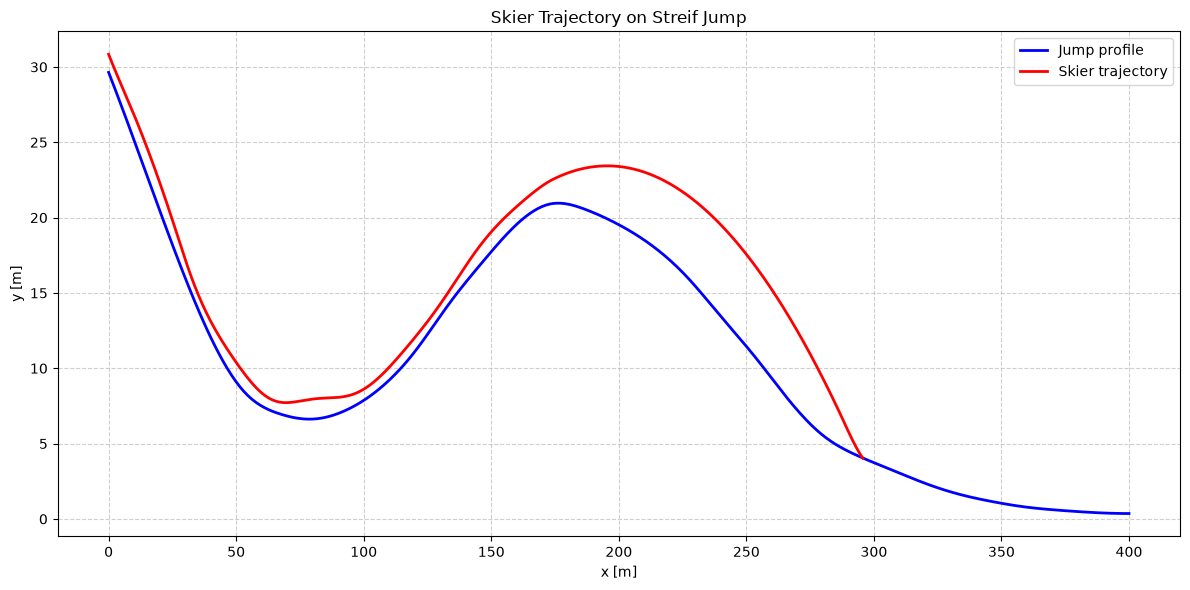

In [7]:

# Trim arrays to actual simulation length
t = t[:time_steps]
pos_x = pos_x[:time_steps]
pos_y = pos_y[:time_steps]
vel_x = vel_x[:time_steps]
vel_y = vel_y[:time_steps]
state = state[:time_steps]

# Plot trajectory
plt.figure(figsize=(12, 6))
plt.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Jump profile')
plt.plot(pos_x, pos_y, 'r-', linewidth=2, label='Skier trajectory')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Skier Trajectory on Streif Jump')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()